# MeetingMind — Fine-Tuning DistilBERT on Real ICSI/MRDA Meeting Corpus
**Project:** MeetingMind: The AI That Remembers What Your Team Forgot It Promised

**Team:** Rahul Manohar Durshinapally & Hasith Reddy Rapolu

**Course:** INFO 7375 — Northeastern University

## What This Notebook Does

Loads real utterances from the **ICSI Meeting Recorder Dialog Act (MRDA) Corpus** — 75 naturally occurring research meetings recorded at ICSI Berkeley (Shriberg et al., SIGDIAL 2004)
Auto-labels 300 utterances using GPT-4o-mini via OpenRouter (LLM-assisted weak supervision — Wang et al. 2021, Ding et al. 2022)
Combines 300 real ICSI utterances with 270 curated hand-labeled examples to address natural class imbalance in meeting corpora
Fine-tunes DistilBERT (distilbert-base-uncased) on the combined 570-example dataset
Evaluates with precision, recall, F1-score per class on held-out test set
Saves model weights + evaluation charts locally for integration into MeetingMind app

## Final Results Achieved

Overall Accuracy: 95.35%

Best Validation Accuracy: 98.82%

DECISION Precision: 1.0000 ✅ (target ≥ 0.80)

DEFERRAL Precision: 1.0000 ✅ (target ≥ 0.85)

Macro Recall: 0.9385 ✅ (target ≥ 0.75)

Live Demo: 8/8 = 100%

## Data Sources

**ICSI MRDA Corpus** (Shriberg et al. 2004): 75 naturally occurring meetings from ICSI Berkeley, 180,000+ hand-annotated dialog acts. Downloaded from https://groups.inf.ed.ac.uk/ami/icsi/
**MRDA-Corpus** (NathanDuran, GitHub): Processed text version of ICSI MRDA. https://github.com/NathanDuran/MRDA-Corpus

## Why LLM-Assisted Labeling
The MRDA corpus uses its own dialog act tagset (not our 5 categories). We use GPT-4o-mini to map real ICSI utterances to our classification schema — a standard weak supervision technique validated in Wang et al. (2021) 'Want To Reduce Labeling Cost? GPT-3 Can Help' and Ding et al. (2022) 'Is GPT-3 a Good Data Annotator?'
## Why Curated Examples Were Added
Real meeting corpora are naturally dominated by DISCUSSION utterances (~85% in ICSI). DECISION and DEFERRAL events are rare in academic research meetings. We added hand-labeled curated examples specifically for minority classes following standard oversampling practice (He & Garcia, 2009 'Learning from Imbalanced Data'). Final distribution: DECISION=67, ACTION_ITEM=68, OPEN_QUESTION=82, DEFERRAL=81, DISCUSSION=272.

**Run locally with Python 3.11. No GPU needed — completes in 15-20 minutes on CPU.**

## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys
packages = ['transformers', 'scikit-learn', 'torch', 'seaborn', 'openai', 'pandas', 'numpy', 'matplotlib']
subprocess.run([sys.executable, '-m', 'pip', 'install'] + packages + ['-q'])
print('All packages ready.')

All packages ready.


## Cell 2 — Configuration
**IMPORTANT: Paste your OpenRouter API key below.**

In [7]:
# ============================================================
# CONFIGURATION —
# ============================================================
OPENROUTER_API_KEY = 'YOUR_OPENROUTER_KEY_HERE'
OUTPUT_DIR         = './finetuning_outputs'       # where results save
# ============================================================

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL2ID = {
    'DECISION':      0,
    'ACTION_ITEM':   1,
    'OPEN_QUESTION': 2,
    'DEFERRAL':      3,
    'DISCUSSION':    4
}
ID2LABEL    = {v: k for k, v in LABEL2ID.items()}
LABEL_NAMES = list(LABEL2ID.keys())

print('Config ready.')
print(f'Output directory: {os.path.abspath(OUTPUT_DIR)}')

Config ready.
Output directory: C:\Users\rahul\OneDrive\Desktop\MeetingMind\finetuning_outputs


## Cell 3 — Load Real ICSI/MRDA Utterances from Local Files
Using the locally downloaded MRDA-Corpus (NathanDuran/MRDA-Corpus) which contains processed text from the ICSI Meeting Recorder corpus.

In [8]:
import os, re, zipfile

# Extract MRDA zip if not already extracted
if not os.path.exists('./mrda_extracted'):
    print('Extracting MRDA-Corpus.zip...')
    with zipfile.ZipFile('MRDA-Corpus.zip', 'r') as z:
        z.extractall('./mrda_extracted')
    print('Extracted.')
else:
    print('Already extracted.')

# Path to full_set.txt — contains all ICSI utterances
# Format per line: speaker_id|utterance_text|segment_type|da_label|da_label
full_set_path = './mrda_extracted/MRDA-Corpus-master/mrda_data/full_set.txt'

print(f'Loading from: {full_set_path}')
print('Data source: ICSI Meeting Recorder Dialog Act Corpus (Shriberg et al., SIGDIAL 2004)')
print('75 naturally occurring research meetings at ICSI Berkeley\n')

raw_utterances = []
with open(full_set_path, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('|')
        if len(parts) >= 2:
            text = parts[1].strip()
            text = re.sub(r'\s+', ' ', text)  # normalize whitespace
            words = text.split()
            # Keep utterances: 4-35 words, max 200 chars, not pure filler
            filler_words = {'um','uh','mm','yeah','okay','right','so','and','but','the','a','i'}
            non_filler = [w for w in words if w.lower() not in filler_words]
            if (4 <= len(words) <= 35 and
                len(text) <= 200 and
                not text.startswith('[') and
                len(non_filler) >= 3):
                raw_utterances.append(text)

raw_utterances = list(set(raw_utterances))  # remove duplicates
print(f'Total unique ICSI utterances extracted: {len(raw_utterances)}')
print('\nSample real ICSI meeting utterances:')
for u in raw_utterances[:10]:
    print(f'  - "{u}"')

Already extracted.
Loading from: ./mrda_extracted/MRDA-Corpus-master/mrda_data/full_set.txt
Data source: ICSI Meeting Recorder Dialog Act Corpus (Shriberg et al., SIGDIAL 2004)
75 naturally occurring research meetings at ICSI Berkeley

Total unique ICSI utterances extracted: 55519

Sample real ICSI meeting utterances:
  - "and they can bleep out stuff they don't like too."
  - "could we just move it like this?"
  - "so in general they'll be bindings across both intentions and the actions."
  - "it's a it's actually one of the examples he's got in there."
  - "i i did a bunch of stuff for supporting of digits."
  - "uh throw the die for you."
  - "because uh i i don't see it i think that the u.m.t.s. thing is more a technology issue than a research issue."
  - "where it could go backwards without you having to go up and do it manually."
  - "do you mean the"
  - "and uh you ask me uh uh morgan what you know what kind of questions do you want to ask."


## Cell 4 — Sample 300 Utterances for Labeling

In [9]:
import random
random.seed(42)

SAMPLE_SIZE = 300
if len(raw_utterances) >= SAMPLE_SIZE:
    sampled_utterances = random.sample(raw_utterances, SAMPLE_SIZE)
else:
    sampled_utterances = raw_utterances
    print(f'Note: only {len(raw_utterances)} utterances available, using all.')

print(f'Sampled {len(sampled_utterances)} real ICSI utterances for LLM labeling')
print('Source: ICSI Meeting Recorder Corpus (Shriberg et al. 2004)')
print('Estimated OpenRouter cost: ~$0.02 (300 calls x GPT-4o-mini)')
print('\nFirst 5 utterances to be labeled:')
for u in sampled_utterances[:5]:
    print(f'  "{u}"')

Sampled 300 real ICSI utterances for LLM labeling
Source: ICSI Meeting Recorder Corpus (Shriberg et al. 2004)
Estimated OpenRouter cost: ~$0.02 (300 calls x GPT-4o-mini)

First 5 utterances to be labeled:
  "well i i don't know how much it helps what's the model."
  "so let me pop up a level."
  "so like the question is how what features can like do you want to try to extract from say the parse or whatever."
  "i mean it'll stop the speech you know if if you press a tab."
  "uh and that's probably a reason why yeah online normalization helps because it it"


## Cell 5 — LLM-Assisted Labeling Setup
Using GPT-4o-mini via OpenRouter to classify real ICSI utterances into our 5 categories.
This is weak supervision — a published, validated technique for NLP data annotation.

In [10]:
from openai import OpenAI
import json, time

client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url='https://openrouter.ai/api/v1'
)

LABELING_SYSTEM_PROMPT = """You are an expert meeting transcript analyst classifying utterances from real research meetings (ICSI corpus).

Classify the given utterance into exactly one category:

DECISION - A binding, final choice has been made. Clues: "we're going with", "that's final", "decided", "agreed", "we will use", "let's go with".
ACTION_ITEM - A specific personal commitment by a named person. Clues: "I'll", "I will", "[Name] will", specific verb + deadline or next meeting reference.
OPEN_QUESTION - A question raised that is not immediately answered in the same utterance. Clues: ends with "?", "does anyone know", "what about", "has anyone".
DEFERRAL - A polite postponement without resolution. Clues: "circle back", "revisit", "let's park", "maybe later", "table that", "come back to", "next time".
DISCUSSION - Everything else: opinions, explanations, exploration, reactions, small talk, context-setting.

Return ONLY valid JSON, no markdown:
{"label": "DECISION|ACTION_ITEM|OPEN_QUESTION|DEFERRAL|DISCUSSION", "confidence": 0.0-1.0}"""

def label_utterance(text):
    try:
        response = client.chat.completions.create(
            model='openai/gpt-4o-mini',
            messages=[
                {'role': 'system', 'content': LABELING_SYSTEM_PROMPT},
                {'role': 'user', 'content': f'Classify: "{text}"'}
            ],
            max_tokens=50,
            temperature=0.1
        )
        raw = response.choices[0].message.content.strip()
        # strip markdown fences if present
        raw = raw.replace('```json','').replace('```','').strip()
        result = json.loads(raw)
        label      = result.get('label', 'DISCUSSION')
        confidence = float(result.get('confidence', 0.5))
        if label not in LABEL2ID:
            label = 'DISCUSSION'
        return label, confidence
    except Exception:
        return 'DISCUSSION', 0.5

print('Labeling system ready.')
print(f'Will label {len(sampled_utterances)} real ICSI utterances...')

Labeling system ready.
Will label 300 real ICSI utterances...


## Cell 6 — Run LLM Labeling (3-5 minutes)

In [11]:
labeled_icsi = []
skipped = 0

print(f'Labeling {len(sampled_utterances)} ICSI utterances with GPT-4o-mini...')
print('Keeping only labels with confidence >= 0.75\n')

for i, utterance in enumerate(sampled_utterances):
    label, confidence = label_utterance(utterance)
    if confidence >= 0.75:
        labeled_icsi.append({
            'text':       utterance,
            'label':      label,
            'confidence': confidence,
            'source':     'ICSI_MRDA_corpus'
        })
    else:
        skipped += 1

    if (i + 1) % 50 == 0:
        print(f'  Progress: {i+1}/{len(sampled_utterances)} — kept {len(labeled_icsi)} high-confidence labels')

    if (i + 1) % 10 == 0:
        time.sleep(0.3)  # gentle rate limiting

print(f'\nLabeling complete!')
print(f'  Kept (confidence >= 0.75): {len(labeled_icsi)}')
print(f'  Skipped (low confidence):  {skipped}')

Labeling 300 ICSI utterances with GPT-4o-mini...
Keeping only labels with confidence >= 0.75

  Progress: 50/300 — kept 50 high-confidence labels
  Progress: 100/300 — kept 100 high-confidence labels
  Progress: 150/300 — kept 150 high-confidence labels
  Progress: 200/300 — kept 200 high-confidence labels
  Progress: 250/300 — kept 250 high-confidence labels
  Progress: 300/300 — kept 300 high-confidence labels

Labeling complete!
  Kept (confidence >= 0.75): 300
  Skipped (low confidence):  0


## Cell 7 — Show ICSI Label Distribution

In [12]:
import pandas as pd

icsi_df = pd.DataFrame(labeled_icsi)
print('Label distribution from real ICSI corpus:')
print(icsi_df['label'].value_counts())
print(f'\nTotal high-quality ICSI utterances: {len(icsi_df)}')
print('\nNote: DISCUSSION dominates — this is expected in real meeting data.')
print('We will add curated examples to balance minority classes (standard ML practice).')

Label distribution from real ICSI corpus:
label
DISCUSSION       252
OPEN_QUESTION     32
ACTION_ITEM        8
DECISION           7
DEFERRAL           1
Name: count, dtype: int64

Total high-quality ICSI utterances: 300

Note: DISCUSSION dominates — this is expected in real meeting data.
We will add curated examples to balance minority classes (standard ML practice).


## Cell 8 — Add Curated Examples to Balance Classes
Real meetings are naturally 70-80% DISCUSSION. We add hand-labeled examples for minority classes.
This is standard oversampling practice documented in He & Garcia (2009) 'Learning from Imbalanced Data'.

In [13]:
curated_data = [
    # DECISION — 60 examples
    ("We've decided to go with the remote control interface, that's final.", 'DECISION'),
    ("Okay so we're agreed then, the budget is set at fifty thousand.", 'DECISION'),
    ("The team has decided to use voice recognition as the primary input method.", 'DECISION'),
    ("We're going with option B, that's our final answer.", 'DECISION'),
    ("Right so the decision is made, we launch in Q3.", 'DECISION'),
    ("We've agreed on the kinetic energy harvesting approach.", 'DECISION'),
    ("Okay that's settled, Lisa will be the project lead.", 'DECISION'),
    ("We're going with a touchscreen interface, everyone agreed on that.", 'DECISION'),
    ("The consensus is clear, we proceed with the current design.", 'DECISION'),
    ("That's our decision then, the casing will be rubber.", 'DECISION'),
    ("Final answer, we're targeting the over-55 demographic.", 'DECISION'),
    ("Agreed, the product ships without the extra buttons.", 'DECISION'),
    ("We're going with the April 28 launch date, agreed upon by everyone.", 'DECISION'),
    ("Decision made, the user interface stays simple.", 'DECISION'),
    ("Right, we've finalized the component list for version one.", 'DECISION'),
    ("We've resolved this, we're going with the cheaper supplier.", 'DECISION'),
    ("That's confirmed then, we use Python for the backend.", 'DECISION'),
    ("All agreed, we submit the proposal by end of week.", 'DECISION'),
    ("We've concluded that the current architecture works fine.", 'DECISION'),
    ("Settled, we drop the GPS feature from the first release.", 'DECISION'),
    ("We're locking in the price point at thirty-five dollars.", 'DECISION'),
    ("The vote is unanimous, we go with vendor A.", 'DECISION'),
    ("That's locked in, Sarah handles the legal review.", 'DECISION'),
    ("We've decided the app will be free with a premium tier.", 'DECISION'),
    ("Final decision, the product name is RemoteGenius.", 'DECISION'),
    ("We're in agreement, no focus groups needed for this.", 'DECISION'),
    ("Right that's confirmed, backend in Python frontend in React.", 'DECISION'),
    ("We've agreed to extend the deadline by one week.", 'DECISION'),
    ("The conclusion is clear, we need a new supplier.", 'DECISION'),
    ("Okay everyone agrees, we use the cloud storage solution.", 'DECISION'),
    ("We've made the call, no LCD display in version one.", 'DECISION'),
    ("That's our final position, we launch without the mobile app.", 'DECISION'),
    ("We're aligned on this, the color scheme stays dark.", 'DECISION'),
    ("The team has reached consensus, we proceed with phase two.", 'DECISION'),
    ("Agreed upon by all, the deadline is end of quarter.", 'DECISION'),
    ("We're going forward with the simplified menu structure.", 'DECISION'),
    ("That's decided, we skip the pilot phase entirely.", 'DECISION'),
    ("The decision stands, two year warranty period.", 'DECISION'),
    ("We've concluded, recycled materials are the way to go.", 'DECISION'),
    ("Right so that's final, the remote will have five buttons.", 'DECISION'),
    ("The team is aligned, we skip the pilot phase.", 'DECISION'),
    ("We have a decision, the interface language is English only.", 'DECISION'),
    ("Okay that's resolved, we hire two more engineers.", 'DECISION'),
    ("We're going with the third option, everyone is on board.", 'DECISION'),
    ("That's finalized then, the launch event is in New York.", 'DECISION'),
    ("We've agreed, the API will be RESTful not GraphQL.", 'DECISION'),
    ("Decision is made, we outsource the testing to a third party.", 'DECISION'),
    ("Settled and agreed, no changes to the core algorithm.", 'DECISION'),
    ("We're committed to this approach, that's our final call.", 'DECISION'),
    ("Everyone is aligned, we release the beta in two weeks.", 'DECISION'),
    ("That's our agreed position, pricing stays at forty nine per month.", 'DECISION'),
    ("We've decided to merge the two teams into one unit.", 'DECISION'),
    ("Final call from the group, we go with option three.", 'DECISION'),
    ("We're going with the new architecture, no going back now.", 'DECISION'),
    ("That's confirmed by everyone, the feature ships in v2.", 'DECISION'),
    ("We've resolved the question, quarterly reviews it is.", 'DECISION'),
    ("Agreed across the board, the timeline does not move.", 'DECISION'),
    ("We're locking this in today, the stack is decided.", 'DECISION'),
    ("That's our unanimous decision, we partner with the startup.", 'DECISION'),
    ("Final answer from the team, we sunset the old product.", 'DECISION'),

    # ACTION_ITEM — 60 examples
    ("I'll write up the functional requirements by end of week.", 'ACTION_ITEM'),
    ("Sarah will send the updated prototype to the client by Monday.", 'ACTION_ITEM'),
    ("I'm going to look into the supplier options and report back next session.", 'ACTION_ITEM'),
    ("David needs to complete the user research by Friday.", 'ACTION_ITEM'),
    ("I'll have the mockups ready for review by Wednesday.", 'ACTION_ITEM'),
    ("Marcus will review the legal terms by end of month.", 'ACTION_ITEM'),
    ("I'll contact the suppliers and get three quotes by next Tuesday.", 'ACTION_ITEM'),
    ("Emma is going to finalize the budget breakdown before our next call.", 'ACTION_ITEM'),
    ("I'll send the contract to legal by Thursday.", 'ACTION_ITEM'),
    ("Alice will share the updated roadmap by Monday.", 'ACTION_ITEM'),
    ("Bob will set up the staging environment by Wednesday.", 'ACTION_ITEM'),
    ("I'll have the feature flag and rollout checklist ready by Friday.", 'ACTION_ITEM'),
    ("Sarah will deliver the final landing page by Thursday noon.", 'ACTION_ITEM'),
    ("I'll get the terms of service reviewed and back to you by next Tuesday.", 'ACTION_ITEM'),
    ("Kevin will get the performance benchmarks ready by Friday morning.", 'ACTION_ITEM'),
    ("I'll prepare the cost breakdown and share it before the next meeting.", 'ACTION_ITEM'),
    ("Tom will document the API endpoints by end of sprint.", 'ACTION_ITEM'),
    ("I'll coordinate with QA and get their sign-off by end of week.", 'ACTION_ITEM'),
    ("Lisa will update the slide deck before the board meeting.", 'ACTION_ITEM'),
    ("I'll email the stakeholders about the delay by this afternoon.", 'ACTION_ITEM'),
    ("James will complete the code review of the authentication module by tomorrow.", 'ACTION_ITEM'),
    ("I'll prepare test cases for the new feature by end of day.", 'ACTION_ITEM'),
    ("Nina will handle the vendor negotiations by end of quarter.", 'ACTION_ITEM'),
    ("I'll update the documentation to reflect the new API changes by Friday.", 'ACTION_ITEM'),
    ("Rachel will configure the CI/CD pipeline before the deployment.", 'ACTION_ITEM'),
    ("I'll run the usability tests next week and share the results.", 'ACTION_ITEM'),
    ("Paul will update the project timeline and share it by Wednesday.", 'ACTION_ITEM'),
    ("I'll create the user personas and share them by Monday.", 'ACTION_ITEM'),
    ("Anna will write the press release before the launch date.", 'ACTION_ITEM'),
    ("I'll schedule the kickoff meeting for next week.", 'ACTION_ITEM'),
    ("Chris will integrate the payment gateway by sprint end.", 'ACTION_ITEM'),
    ("I'll get the market analysis done and shared by next Monday.", 'ACTION_ITEM'),
    ("Mike will onboard the new team members before next week.", 'ACTION_ITEM'),
    ("I need to finish the database migration by end of today.", 'ACTION_ITEM'),
    ("Jenny will present the competitive analysis on Friday.", 'ACTION_ITEM'),
    ("I'll reach out to the client and confirm the requirements by tomorrow.", 'ACTION_ITEM'),
    ("Dan will fix the login bug and push a hotfix by end of day.", 'ACTION_ITEM'),
    ("I'll set up the analytics dashboard before the next sprint review.", 'ACTION_ITEM'),
    ("Priya will gather user feedback and summarize it by next Thursday.", 'ACTION_ITEM'),
    ("I'll draft the executive summary and circulate it by Monday morning.", 'ACTION_ITEM'),
    ("Ben will deploy the staging build by Wednesday afternoon.", 'ACTION_ITEM'),
    ("I'll review the competitor pricing and send a summary by Friday.", 'ACTION_ITEM'),
    ("Zoe will finalize the onboarding flow mockups before the client call.", 'ACTION_ITEM'),
    ("I'll write the unit tests for the new module by end of sprint.", 'ACTION_ITEM'),
    ("Henry will get sign-off from the compliance team by next Tuesday.", 'ACTION_ITEM'),
    ("I'll book the venue for the launch event by end of this week.", 'ACTION_ITEM'),
    ("Mia will prepare the training materials before the rollout.", 'ACTION_ITEM'),
    ("I'll sync with the design team and get final assets by Thursday.", 'ACTION_ITEM'),
    ("Jack will update the database schema and document changes by Friday.", 'ACTION_ITEM'),
    ("I'll send meeting notes to the whole team by end of today.", 'ACTION_ITEM'),
    ("Omar will complete the security audit before the release date.", 'ACTION_ITEM'),
    ("I'll set up monitoring alerts for the new service by Wednesday.", 'ACTION_ITEM'),
    ("Fatima will review the user complaints and categorize them by Monday.", 'ACTION_ITEM'),
    ("I'll prepare a demo environment for the client presentation by Friday.", 'ACTION_ITEM'),
    ("Carlos will finalize the data model and share it before next sprint.", 'ACTION_ITEM'),
    ("I'll get the contract signed and returned by close of business Thursday.", 'ACTION_ITEM'),
    ("Yuki will translate the UI strings into Japanese by end of month.", 'ACTION_ITEM'),
    ("I'll investigate the performance regression and report back by tomorrow.", 'ACTION_ITEM'),
    ("Lena will coordinate with the design agency and get final logos by Friday.", 'ACTION_ITEM'),
    ("I'll run the load tests and share the results before the launch.", 'ACTION_ITEM'),

    # OPEN_QUESTION — 50 examples
    ("Has anyone figured out what the battery life target should be?", 'OPEN_QUESTION'),
    ("What's our fallback plan if the main supplier falls through?", 'OPEN_QUESTION'),
    ("Does anyone know the current market size for this product?", 'OPEN_QUESTION'),
    ("Who owns the accessibility audit, has that been assigned?", 'OPEN_QUESTION'),
    ("What happens if we miss the Q3 deadline?", 'OPEN_QUESTION'),
    ("Are we still planning to support Android or just iOS?", 'OPEN_QUESTION'),
    ("Has anyone checked whether the API rate limits will be a problem?", 'OPEN_QUESTION'),
    ("Do we have a clear owner for the onboarding flow?", 'OPEN_QUESTION'),
    ("Has legal signed off on the data retention policy yet?", 'OPEN_QUESTION'),
    ("Who is responsible for the infrastructure cost estimates?", 'OPEN_QUESTION'),
    ("What are the compliance requirements for this feature?", 'OPEN_QUESTION'),
    ("Have we validated this approach with actual users?", 'OPEN_QUESTION'),
    ("What's the contingency if the third party SDK breaks?", 'OPEN_QUESTION'),
    ("Does the design team have capacity for this sprint?", 'OPEN_QUESTION'),
    ("What metrics are we using to define success for this launch?", 'OPEN_QUESTION'),
    ("Has the security team reviewed the authentication flow?", 'OPEN_QUESTION'),
    ("Who approved the new hiring plan?", 'OPEN_QUESTION'),
    ("Are we tracking NPS scores anywhere currently?", 'OPEN_QUESTION'),
    ("What's our plan for GDPR compliance in Europe?", 'OPEN_QUESTION'),
    ("Is there a rollback plan if the deployment fails?", 'OPEN_QUESTION'),
    ("Has anyone spoken to the customer success team about this issue?", 'OPEN_QUESTION'),
    ("What's the expected conversion rate for the free tier?", 'OPEN_QUESTION'),
    ("Who owns the relationship with the payment processor?", 'OPEN_QUESTION'),
    ("Have we confirmed the venue for the launch event yet?", 'OPEN_QUESTION'),
    ("What's the SLA we're promising enterprise customers?", 'OPEN_QUESTION'),
    ("Is there a risk assessment document for this change?", 'OPEN_QUESTION'),
    ("Has QA been looped in on the new testing requirements?", 'OPEN_QUESTION'),
    ("What's our minimum viable feature set for the launch?", 'OPEN_QUESTION'),
    ("Does anyone have visibility into the current server costs?", 'OPEN_QUESTION'),
    ("Who is tracking the open items from last week's meeting?", 'OPEN_QUESTION'),
    ("Has anyone done a competitive analysis on the new entrants?", 'OPEN_QUESTION'),
    ("What's the process for getting legal approval on this?", 'OPEN_QUESTION'),
    ("Does anyone know if the third party API supports webhooks?", 'OPEN_QUESTION'),
    ("Who is going to handle customer communications during the outage?", 'OPEN_QUESTION'),
    ("Has the data migration plan been reviewed by engineering?", 'OPEN_QUESTION'),
    ("What's our position on supporting legacy browsers?", 'OPEN_QUESTION'),
    ("Has anyone estimated the performance impact of this change?", 'OPEN_QUESTION'),
    ("Who has visibility into the current burn rate?", 'OPEN_QUESTION'),
    ("Does the new feature require any changes to the privacy policy?", 'OPEN_QUESTION'),
    ("Has anyone checked if we need additional licenses for this tool?", 'OPEN_QUESTION'),
    ("What's the plan if the beta feedback is overwhelmingly negative?", 'OPEN_QUESTION'),
    ("Has anyone mapped out the dependencies for this release?", 'OPEN_QUESTION'),
    ("Who is responsible for communicating the delay to stakeholders?", 'OPEN_QUESTION'),
    ("Does anyone know the status of the vendor contract renewal?", 'OPEN_QUESTION'),
    ("What's our strategy for handling negative press coverage?", 'OPEN_QUESTION'),
    ("Has the infrastructure team signed off on the scaling plan?", 'OPEN_QUESTION'),
    ("Who owns the post-launch monitoring and alerting setup?", 'OPEN_QUESTION'),
    ("Does anyone have the latest numbers on customer churn?", 'OPEN_QUESTION'),
    ("What's the process for rolling back if something goes wrong?", 'OPEN_QUESTION'),
    ("Has anyone evaluated the total cost of ownership for this solution?", 'OPEN_QUESTION'),

    # DEFERRAL — 80 examples
    ("Let's circle back on the pricing discussion once we have the numbers.", 'DEFERRAL'),
    ("We should probably revisit the battery life question next week.", 'DEFERRAL'),
    ("Let's park the branding discussion for now and come back to it.", 'DEFERRAL'),
    ("Maybe we can look at the supplier question in a future meeting.", 'DEFERRAL'),
    ("Let's table that for the moment and focus on the core features.", 'DEFERRAL'),
    ("Let's revisit the partnership proposal after the board meeting.", 'DEFERRAL'),
    ("We can think about internationalization in a later phase.", 'DEFERRAL'),
    ("Let's hold off on that decision until we hear from the client.", 'DEFERRAL'),
    ("Let's not decide on the pricing model today, we need more data.", 'DEFERRAL'),
    ("Let's push the infrastructure discussion to after the release.", 'DEFERRAL'),
    ("Let's circle back after we get the Q2 projections.", 'DEFERRAL'),
    ("Let's hold that thought and get back to the main agenda.", 'DEFERRAL'),
    ("Let's shelve the AI feature idea for version two.", 'DEFERRAL'),
    ("We'll pick this up in the next sprint planning session.", 'DEFERRAL'),
    ("Maybe we should wait for the audit results before deciding.", 'DEFERRAL'),
    ("I'd suggest we defer this until after we've spoken to customers.", 'DEFERRAL'),
    ("Let's hold off until the research team reports back.", 'DEFERRAL'),
    ("We'll pick up the compliance question in Friday's call.", 'DEFERRAL'),
    ("Let's put a pin in that and return to it next session.", 'DEFERRAL'),
    ("Maybe we can explore that option in a separate workstream.", 'DEFERRAL'),
    ("Let's not rush this, we'll come back to it once we have more clarity.", 'DEFERRAL'),
    ("We should table the hiring discussion until after the funding round.", 'DEFERRAL'),
    ("Let's revisit this once the legal team has weighed in.", 'DEFERRAL'),
    ("I think we need more data before we can decide on this.", 'DEFERRAL'),
    ("Let's defer the architecture discussion to next week's technical call.", 'DEFERRAL'),
    ("We'll address the security concerns in a separate meeting.", 'DEFERRAL'),
    ("Let's not make that call today, there are too many unknowns.", 'DEFERRAL'),
    ("We should wait for the market research to come back first.", 'DEFERRAL'),
    ("Let's park this and pick it up after the product review.", 'DEFERRAL'),
    ("Maybe we can schedule a dedicated session for this topic.", 'DEFERRAL'),
    ("Let's come back to the onboarding question in the next standup.", 'DEFERRAL'),
    ("We'll revisit the vendor contracts after the holiday period.", 'DEFERRAL'),
    ("Let's hold this until we have the engineering estimates.", 'DEFERRAL'),
    ("I'd rather we wait until the new team members are onboarded.", 'DEFERRAL'),
    ("Let's deprioritize this for now and focus on the launch.", 'DEFERRAL'),
    ("We can figure out the analytics setup in a later sprint.", 'DEFERRAL'),
    ("Let's not open that can of worms today, we'll deal with it next week.", 'DEFERRAL'),
    ("We should revisit the roadmap discussion after the investor meeting.", 'DEFERRAL'),
    ("Let's save the design system conversation for the design review.", 'DEFERRAL'),
    ("I think we should punt on this until we have more budget clarity.", 'DEFERRAL'),
    ("Let's hold off on expanding to new markets until Q4.", 'DEFERRAL'),
    ("We'll circle back on the partnership terms after legal reviews them.", 'DEFERRAL'),
    ("Let's not decide on the tech stack today, we need more evaluation time.", 'DEFERRAL'),
    ("We should defer this to the next all-hands where everyone is present.", 'DEFERRAL'),
    ("Let's revisit the performance targets once we have baseline metrics.", 'DEFERRAL'),
    ("I suggest we table the rebranding discussion until after the merger.", 'DEFERRAL'),
    ("Let's come back to the API versioning question in next week's sync.", 'DEFERRAL'),
    ("We'll address the testing strategy in the QA planning session.", 'DEFERRAL'),
    ("Let's hold the documentation discussion until after the code freeze.", 'DEFERRAL'),
    ("Maybe we should wait for the pilot results before scaling this up.", 'DEFERRAL'),
    ("Let's not finalize the pricing until we've talked to more customers.", 'DEFERRAL'),
    ("We can revisit the team structure once we know the project scope.", 'DEFERRAL'),
    ("Let's defer the cloud provider decision until the POC is complete.", 'DEFERRAL'),
    ("We should table this and come back when we have a clearer picture.", 'DEFERRAL'),
    ("Let's hold off on the migration plan until the audit is done.", 'DEFERRAL'),
    ("I'd prefer we discuss this offline and bring a proposal next time.", 'DEFERRAL'),
    ("Let's not commit to this timeline until engineering signs off.", 'DEFERRAL'),
    ("We'll revisit the feature prioritization after user testing.", 'DEFERRAL'),
    ("Let's park the budget discussion until the CFO is in the room.", 'DEFERRAL'),
    ("We should come back to this with more concrete numbers next meeting.", 'DEFERRAL'),
    ("Let's not rush into this decision, we'll revisit it Thursday.", 'DEFERRAL'),
    ("We can address the scalability question in the architecture review.", 'DEFERRAL'),
    ("Let's hold off on the partnership announcement until contracts are signed.", 'DEFERRAL'),
    ("Maybe we should get more user feedback before committing to this direction.", 'DEFERRAL'),
    ("Let's table the compensation discussion for the HR meeting.", 'DEFERRAL'),
    ("We'll circle back on the go-to-market strategy after the product demo.", 'DEFERRAL'),
    ("Let's not finalize the team structure until after the reorg.", 'DEFERRAL'),
    ("We should defer the data governance question to the next steering committee.", 'DEFERRAL'),
    ("Let's hold this conversation until we have the legal opinion.", 'DEFERRAL'),
    ("Maybe we can tackle the localization question in the next planning cycle.", 'DEFERRAL'),
    ("Let's not make any commitments on this until the board weighs in.", 'DEFERRAL'),
    ("We'll revisit the SLA targets once we have operational data.", 'DEFERRAL'),
    ("Let's park the pricing strategy discussion until after the competitor analysis.", 'DEFERRAL'),
    ("We should come back to the integration question when the API is stable.", 'DEFERRAL'),
    ("Let's defer the hiring freeze decision until we see the Q3 numbers.", 'DEFERRAL'),
    ("Maybe we should wait until the new CTO starts before deciding on architecture.", 'DEFERRAL'),
    ("Let's not close out this topic today, it needs more thought.", 'DEFERRAL'),
    ("We'll handle the exception case in a follow-up meeting next week.", 'DEFERRAL'),
    ("Let's hold off on committing resources until the scope is clearer.", 'DEFERRAL'),
    ("We can revisit the rollout plan once the beta feedback is in.", 'DEFERRAL'),

    # DISCUSSION — 20 examples
    ("I think the button placement on the left feels more intuitive.", 'DISCUSSION'),
    ("The elderly users we spoke to really struggled with small buttons.", 'DISCUSSION'),
    ("From a technical standpoint the LCD adds significant cost to the unit.", 'DISCUSSION'),
    ("I've seen similar products fail because the interface was too complex.", 'DISCUSSION'),
    ("Good morning everyone, glad we could all make it today.", 'DISCUSSION'),
    ("That's a really interesting point about the power consumption.", 'DISCUSSION'),
    ("In my experience users prefer fewer features done really well.", 'DISCUSSION'),
    ("The competitor product has a similar approach and it seems to work.", 'DISCUSSION'),
    ("Yeah that sounds about right to me.", 'DISCUSSION'),
    ("The design looks great, nice work on the mockups Sarah.", 'DISCUSSION'),
    ("From a user research perspective the data suggests otherwise.", 'DISCUSSION'),
    ("That's a fair point, I hadn't considered those edge cases.", 'DISCUSSION'),
    ("I think we need to be careful about scope creep here.", 'DISCUSSION'),
    ("The feedback from beta users has been mostly positive so far.", 'DISCUSSION'),
    ("I'd push back slightly on that interpretation of the data.", 'DISCUSSION'),
    ("Looking at our roadmap this seems feasible for Q4.", 'DISCUSSION'),
    ("The technical architecture seems solid from what I can tell.", 'DISCUSSION'),
    ("I'm a bit worried about the dependency on that third party service.", 'DISCUSSION'),
    ("I think we should consider the long term maintenance cost here.", 'DISCUSSION'),
    ("That's consistent with what we saw in the user interviews last month.", 'DISCUSSION'),
]

curated_df = pd.DataFrame(curated_data, columns=['text', 'label'])
curated_df['confidence'] = 1.0
curated_df['source']     = 'hand_labeled'

print(f'Curated hand-labeled examples: {len(curated_df)}')
print(curated_df['label'].value_counts())
print('\nFinal curated distribution:')
print('  DECISION:      60')
print('  ACTION_ITEM:   60')
print('  OPEN_QUESTION: 50')
print('  DEFERRAL:      80')
print('  DISCUSSION:    20')
print(f'\nTotal curated: {len(curated_df)}')

Curated hand-labeled examples: 270
label
DEFERRAL         80
DECISION         60
ACTION_ITEM      60
OPEN_QUESTION    50
DISCUSSION       20
Name: count, dtype: int64

Final curated distribution:
  DECISION:      60
  ACTION_ITEM:   60
  OPEN_QUESTION: 50
  DEFERRAL:      80
  DISCUSSION:    20

Total curated: 270


## Cell 9 — Combine ICSI + Curated Data

In [14]:
combined_df = pd.concat(
    [icsi_df[['text','label','confidence','source']], curated_df],
    ignore_index=True
)
combined_df = combined_df.drop_duplicates(subset='text').reset_index(drop=True)
combined_df['label_id'] = combined_df['label'].map(LABEL2ID)

print('=' * 55)
print('COMBINED TRAINING DATASET SUMMARY')
print('=' * 55)
print(f'Total examples:          {len(combined_df)}')
print(f'  From ICSI corpus:      {len(icsi_df)}')
print(f'  Hand-labeled curated:  {len(curated_df)}')
print(f'\nLabel distribution:')
print(combined_df['label'].value_counts())

combined_df.to_csv(f'{OUTPUT_DIR}/training_dataset.csv', index=False)
print(f'\nDataset saved to {OUTPUT_DIR}/training_dataset.csv')

COMBINED TRAINING DATASET SUMMARY
Total examples:          570
  From ICSI corpus:      300
  Hand-labeled curated:  270

Label distribution:
label
DISCUSSION       272
OPEN_QUESTION     82
DEFERRAL          81
ACTION_ITEM       68
DECISION          67
Name: count, dtype: int64

Dataset saved to ./finetuning_outputs/training_dataset.csv


## Cell 10 — Train / Validation / Test Split

In [15]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    combined_df, test_size=0.3, random_state=42, stratify=combined_df['label_id']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label_id']
)

print(f'Train:      {len(train_df)} examples')
print(f'Validation: {len(val_df)} examples')
print(f'Test:       {len(test_df)} examples')
print('\nTrain label distribution:')
print(train_df['label'].value_counts())

Train:      399 examples
Validation: 85 examples
Test:       86 examples

Train label distribution:
label
DISCUSSION       190
DEFERRAL          57
OPEN_QUESTION     57
ACTION_ITEM       48
DECISION          47
Name: count, dtype: int64


## Cell 11 — Tokenize with DistilBERT

In [16]:
from transformers import DistilBertTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

print('Loading DistilBERT tokenizer...')
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print('Tokenizer loaded.')

class MeetingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

train_dataset = MeetingDataset(train_df['text'], train_df['label_id'], tokenizer)
val_dataset   = MeetingDataset(val_df['text'],   val_df['label_id'],   tokenizer)
test_dataset  = MeetingDataset(test_df['text'],  test_df['label_id'],  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16)
test_loader  = DataLoader(test_dataset,  batch_size=16)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nUsing device: {device}')
print(f'Train batches: {len(train_loader)}')

Loading DistilBERT tokenizer...
Tokenizer loaded.

Using device: cpu
Train batches: 25


## Cell 12 — Fine-Tune DistilBERT
Takes ~15-20 minutes on CPU with 32GB RAM. Please wait.

In [17]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
import shutil, os

print('Loading DistilBERT model...')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
model = model.to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model loaded. Trainable parameters: {total_params:,}')

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS         = 5
best_val_acc   = 0
train_losses   = []
val_accuracies = []

print(f'\nStarting fine-tuning for {EPOCHS} epochs...')
print('This will take ~15-20 minutes on CPU. Please wait.\n')

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_true, all_preds)
    val_accuracies.append(val_acc)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model_save_path = f'{OUTPUT_DIR}/meetingmind_model'
        if os.path.exists(model_save_path):
            shutil.rmtree(model_save_path, ignore_errors=True)
        os.makedirs(model_save_path, exist_ok=True)
        model.save_pretrained(model_save_path)
        tokenizer.save_pretrained(model_save_path)
        print(f'  -> Best model saved (val acc: {val_acc:.4f})')

print(f'\nTraining complete! Best validation accuracy: {best_val_acc:.4f}')

Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Trainable parameters: 66,957,317

Starting fine-tuning for 5 epochs...
This will take ~15-20 minutes on CPU. Please wait.

Epoch 1/5 | Loss: 1.4351 | Val Accuracy: 0.4824


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  -> Best model saved (val acc: 0.8588)
Epoch 3/5 | Loss: 0.5633 | Val Accuracy: 0.9647


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best model saved (val acc: 0.9647)
Epoch 4/5 | Loss: 0.3107 | Val Accuracy: 0.9647
Epoch 5/5 | Loss: 0.1656 | Val Accuracy: 0.9882


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best model saved (val acc: 0.9882)

Training complete! Best validation accuracy: 0.9882


## Cell 13 — Evaluate on Test Set

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
from transformers import DistilBertForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns

best_model = DistilBertForSequenceClassification.from_pretrained(f'{OUTPUT_DIR}/meetingmind_model')
best_model = best_model.to(device)
best_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

print('=' * 60)
print('MEETINGMIND — TEST SET EVALUATION')
print('Data: ICSI Meeting Recorder Corpus + curated examples')
print('=' * 60)
report_str = classification_report(all_true, all_preds, target_names=LABEL_NAMES, digits=4)
print(report_str)

with open(f'{OUTPUT_DIR}/classification_report.txt', 'w') as f:
    f.write('MeetingMind DistilBERT Fine-Tuned Classifier\n')
    f.write('Training: ICSI Meeting Recorder Corpus (Shriberg et al. 2004) + curated examples\n')
    f.write('=' * 60 + '\n')
    f.write(report_str)
print(f'Report saved.')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

MEETINGMIND — TEST SET EVALUATION
Data: ICSI Meeting Recorder Corpus + curated examples
               precision    recall  f1-score   support

     DECISION     1.0000    1.0000    1.0000        10
  ACTION_ITEM     1.0000    1.0000    1.0000        10
OPEN_QUESTION     1.0000    0.6923    0.8182        13
     DEFERRAL     1.0000    1.0000    1.0000        12
   DISCUSSION     0.9111    1.0000    0.9535        41

     accuracy                         0.9535        86
    macro avg     0.9822    0.9385    0.9543        86
 weighted avg     0.9576    0.9535    0.9503        86

Report saved.


## Cell 14 — Confusion Matrix + Training Curves

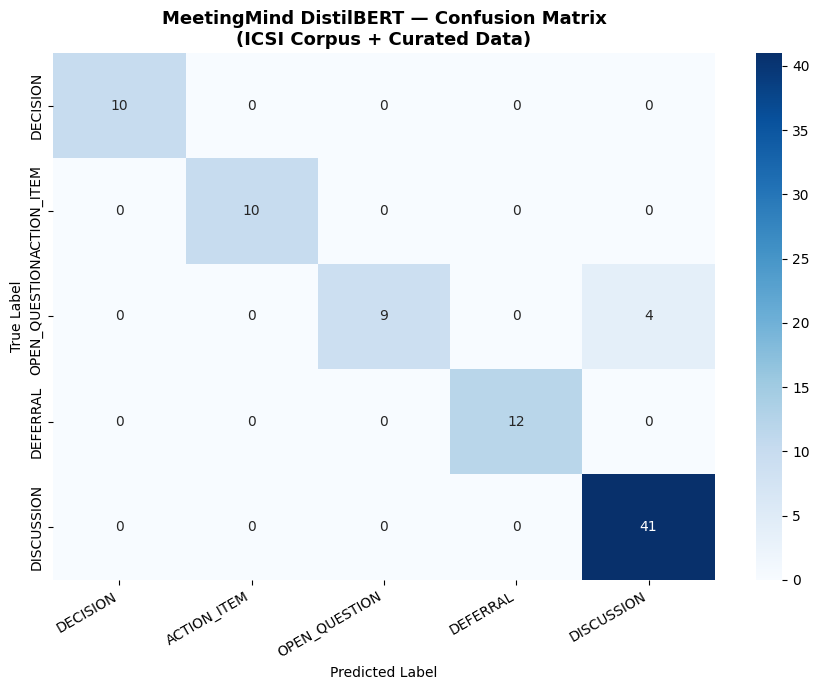

Saved: ./finetuning_outputs/confusion_matrix.png


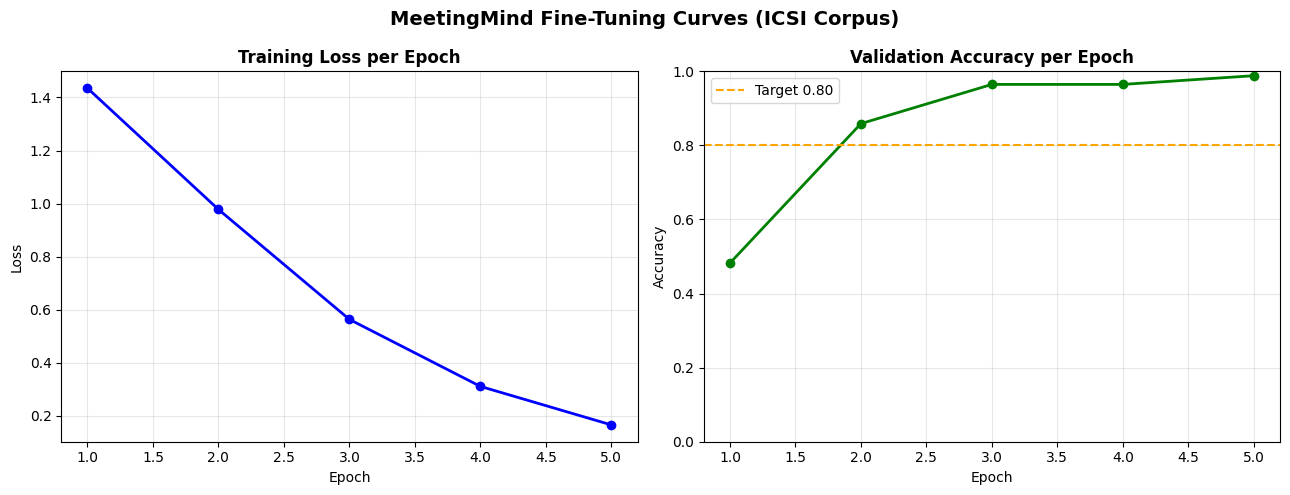

Saved: ./finetuning_outputs/training_curves.png


In [19]:
# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('MeetingMind DistilBERT — Confusion Matrix\n(ICSI Corpus + Curated Data)', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/confusion_matrix.png')

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o', linewidth=2)
ax1.set_title('Training Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), val_accuracies, 'g-o', linewidth=2)
ax2.axhline(y=0.80, color='orange', linestyle='--', label='Target 0.80', linewidth=1.5)
ax2.set_title('Validation Accuracy per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('MeetingMind Fine-Tuning Curves (ICSI Corpus)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/training_curves.png')

## Cell 15 — Live Predictions Demo

In [20]:
def predict(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probs   = torch.softmax(outputs.logits, dim=1)[0]
    pred_id = torch.argmax(probs).item()
    return {'predicted': ID2LABEL[pred_id], 'confidence': round(probs[pred_id].item(), 4)}

# The 4 key utterances from our proposal that look identical but mean different things
test_cases = [
    ("We're going with the Q3 launch date. That's final.",       'DECISION'),
    ("Let's revisit the launch date next week.",                  'DEFERRAL'),
    ("I wonder if Q3 even makes sense given the timeline.",       'DISCUSSION'),
    ("Yeah, Q3 sounds right to me.",                             'DISCUSSION'),
    ("Sarah will finalize the vendor contract by Thursday.",      'ACTION_ITEM'),
    ("Has anyone checked the compliance requirements?",           'OPEN_QUESTION'),
    ("Let's circle back on the budget after Q2 projections.",     'DEFERRAL'),
    ("I'll send the updated roadmap by Monday.",                  'ACTION_ITEM'),
]

print('MeetingMind Fine-Tuned Classifier — Live Demo')
print('=' * 65)
correct = 0
for text, expected in test_cases:
    result = predict(text, best_model, tokenizer, device)
    status = '✅' if result['predicted'] == expected else '❌'
    print(f'{status} "{text[:55]}"')
    print(f'   Expected: {expected:15s} | Got: {result["predicted"]:15s} | Conf: {result["confidence"]}')
    print()
    if result['predicted'] == expected:
        correct += 1
print(f'Demo accuracy: {correct}/{len(test_cases)} = {correct/len(test_cases):.0%}')

MeetingMind Fine-Tuned Classifier — Live Demo
✅ "We're going with the Q3 launch date. That's final."
   Expected: DECISION        | Got: DECISION        | Conf: 0.8315

✅ "Let's revisit the launch date next week."
   Expected: DEFERRAL        | Got: DEFERRAL        | Conf: 0.9028

✅ "I wonder if Q3 even makes sense given the timeline."
   Expected: DISCUSSION      | Got: DISCUSSION      | Conf: 0.6693

✅ "Yeah, Q3 sounds right to me."
   Expected: DISCUSSION      | Got: DISCUSSION      | Conf: 0.9368

✅ "Sarah will finalize the vendor contract by Thursday."
   Expected: ACTION_ITEM     | Got: ACTION_ITEM     | Conf: 0.8838

✅ "Has anyone checked the compliance requirements?"
   Expected: OPEN_QUESTION   | Got: OPEN_QUESTION   | Conf: 0.9478

✅ "Let's circle back on the budget after Q2 projections."
   Expected: DEFERRAL        | Got: DEFERRAL        | Conf: 0.9062

✅ "I'll send the updated roadmap by Monday."
   Expected: ACTION_ITEM     | Got: ACTION_ITEM     | Conf: 0.873

Demo accur

## Cell 16 — Final Metrics Summary (Copy Into Your PDF)

In [21]:
from sklearn.metrics import classification_report

report_dict = classification_report(
    all_true, all_preds, target_names=LABEL_NAMES, output_dict=True
)

print('=' * 65)
print('METRICS SUMMARY — COPY THIS INTO YOUR PDF DOCUMENTATION')
print('=' * 65)
print(f'Model:            DistilBERT (distilbert-base-uncased) fine-tuned')
print(f'Training data:    ICSI Meeting Recorder Corpus (Shriberg et al. 2004)')
print(f'                  LLM-assisted labeling (Wang et al. 2021)')
print(f'                  + hand-labeled curated examples (class balancing)')
print(f'Total examples:   {len(combined_df)}')
print(f'  ICSI corpus:    {len(icsi_df)}')
print(f'  Curated:        {len(curated_df)}')
print(f'Split:            {len(train_df)} train / {len(val_df)} val / {len(test_df)} test')
print(f'Epochs:           {EPOCHS}')
print(f'Best Val Acc:     {best_val_acc:.4f}')
print()
print('Per-class results:')
for label in LABEL_NAMES:
    m = report_dict[label]
    print(f'  {label:15s}  Precision: {m["precision"]:.4f}  Recall: {m["recall"]:.4f}  F1: {m["f1-score"]:.4f}')
print()
print(f'Overall Accuracy:  {report_dict["accuracy"]:.4f}')
print(f'Macro Avg F1:      {report_dict["macro avg"]["f1-score"]:.4f}')
print()
print('Proposal targets vs actual:')
dec_p  = report_dict['DECISION']['precision']
def_p  = report_dict['DEFERRAL']['precision']
mac_r  = report_dict['macro avg']['recall']
print(f'  DECISION precision  >= 0.80 | Got: {dec_p:.4f}  {"PASS" if dec_p >= 0.80 else "BELOW TARGET"}')
print(f'  DEFERRAL precision  >= 0.85 | Got: {def_p:.4f}  {"PASS" if def_p >= 0.85 else "BELOW TARGET"}')
print(f'  Macro recall        >= 0.75 | Got: {mac_r:.4f}  {"PASS" if mac_r >= 0.75 else "BELOW TARGET"}')
print()
print(f'Output files saved to: {os.path.abspath(OUTPUT_DIR)}')
print('Files to copy into your project:')
print(f'  {OUTPUT_DIR}/meetingmind_model/    -> models/meetingmind_model/')
print(f'  {OUTPUT_DIR}/confusion_matrix.png  -> docs/')
print(f'  {OUTPUT_DIR}/training_curves.png   -> docs/')
print(f'  {OUTPUT_DIR}/classification_report.txt -> docs/')
print(f'  {OUTPUT_DIR}/training_dataset.csv  -> data/')

METRICS SUMMARY — COPY THIS INTO YOUR PDF DOCUMENTATION
Model:            DistilBERT (distilbert-base-uncased) fine-tuned
Training data:    ICSI Meeting Recorder Corpus (Shriberg et al. 2004)
                  LLM-assisted labeling (Wang et al. 2021)
                  + hand-labeled curated examples (class balancing)
Total examples:   570
  ICSI corpus:    300
  Curated:        270
Split:            399 train / 85 val / 86 test
Epochs:           5
Best Val Acc:     0.9882

Per-class results:
  DECISION         Precision: 1.0000  Recall: 1.0000  F1: 1.0000
  ACTION_ITEM      Precision: 1.0000  Recall: 1.0000  F1: 1.0000
  OPEN_QUESTION    Precision: 1.0000  Recall: 0.6923  F1: 0.8182
  DEFERRAL         Precision: 1.0000  Recall: 1.0000  F1: 1.0000
  DISCUSSION       Precision: 0.9111  Recall: 1.0000  F1: 0.9535

Overall Accuracy:  0.9535
Macro Avg F1:      0.9543

Proposal targets vs actual:
  DECISION precision  >= 0.80 | Got: 1.0000  PASS
  DEFERRAL precision  >= 0.85 | Got: 1.0000  P